<a href="https://colab.research.google.com/github/ayyanarh1/tamil-nadu-school-flood-risk/blob/main/day5_ssp_projections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup
!pip install cdsapi xarray netCDF4 matplotlib
!pip install geopandas folium pandas numpy -q

import cdsapi
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

print('✅ Day 5 ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.7 MB/s eta 0:00:00
✅ Day 5 ready!


In [2]:
# Configure CDS API
import os
import cdsapi

#  CDS API key here (same as Day 4)
cds_key = "497dbf43-98f6-46cc-b8e3-95f23bd9df65"

config = f"""url: https://cds.climate.copernicus.eu/api
key: {cds_key}
"""

with open(os.path.expanduser('~/.cdsapirc'), 'w') as f:
    f.write(config)

c = cdsapi.Client()
print('✅ CDS API ready!')

✅ CDS API ready!


In [6]:
# Delta method for 2050 projections
# No download needed — uses ERA5 data from Day 4
import pandas as pd
import numpy as np

print('Building 2050 climate projections using delta method...')
print('(Same approach used by World Bank and UNICEF risk teams)\n')

# Current baseline rainfall per school (from Day 4)
baseline_data = {
    'school_name': [
        'School Puducherry Border',
        'Panchayat School Nagapattinam',
        'School Ramanathapuram',
        'Govt School Cuddalore',
        'School Tuticorin',
        'School Kanchipuram',
        'Govt School Tiruchirappalli',
        'Panchayat School Tirunelveli',
        'Govt School Thanjavur',
        'High School Vellore',
        'School Villupuram',
        'Govt School Madurai',
        'Govt High School Chennai',
        'High School Coimbatore',
        'Govt School Salem'
    ],
    'connectivity': [
        'connected', 'none', 'none', 'none',
        'connected', 'none', 'none', 'none',
        'connected', 'connected', 'none',
        'connected', 'connected', 'connected', 'connected'
    ],
    'current_score': [
        96.7, 56.8, 43.5, 39.8, 39.1,
        33.3, 31.4, 30.7, 26.5, 22.1,
        22.9, 13.0, 13.8, 4.8, 4.9
    ],
    'current_risk': [
        'CRITICAL', 'CRITICAL', 'HIGH', 'HIGH', 'HIGH',
        'HIGH', 'HIGH', 'HIGH', 'HIGH', 'MEDIUM',
        'MEDIUM', 'MEDIUM', 'MEDIUM', 'LOW', 'LOW'
    ],
    'oct_dec_rainfall_mm': [
        7.7, 9.2, 7.9, 8.1, 7.8,
        6.2, 5.2, 7.4, 6.3, 5.3,
        6.1, 5.8, 7.8, 4.4, 4.5
    ]
}

df = pd.DataFrame(baseline_data)

# ── Delta method ──
# IPCC AR6 projections for South Asia:
# SSP2-4.5: +15% increase in extreme rainfall by 2050
# SSP5-8.5: +30% increase in extreme rainfall by 2050
# Source: IPCC AR6 WGI Chapter 11 — South Asia region

SSP245_DELTA = 1.15  # 15% increase
SSP585_DELTA = 1.30  # 30% increase

# Apply delta to current risk scores
# Higher rainfall → higher flood probability → higher risk score
df['score_ssp245'] = (df['current_score'] * SSP245_DELTA).round(1)
df['score_ssp585'] = (df['current_score'] * SSP585_DELTA).round(1)

df['rain_ssp245'] = (df['oct_dec_rainfall_mm'] * SSP245_DELTA).round(1)
df['rain_ssp585'] = (df['oct_dec_rainfall_mm'] * SSP585_DELTA).round(1)

# Cap scores at 100
df['score_ssp245'] = df['score_ssp245'].clip(upper=100)
df['score_ssp585'] = df['score_ssp585'].clip(upper=100)

# Risk tiers for future scenarios
def get_risk(score):
    if score >= 50:   return 'CRITICAL'
    elif score >= 25: return 'HIGH'
    elif score >= 10: return 'MEDIUM'
    else:             return 'LOW'

df['risk_ssp245'] = df['score_ssp245'].apply(get_risk)
df['risk_ssp585'] = df['score_ssp585'].apply(get_risk)

# Schools that change risk tier
df['tier_change_245'] = df['current_risk'] != df['risk_ssp245']
df['tier_change_585'] = df['current_risk'] != df['risk_ssp585']

print('=== 2050 CLIMATE PROJECTIONS — TAMIL NADU SCHOOLS ===')
print('Current vs SSP2-4.5 (+15%) vs SSP5-8.5 (+30%)\n')
print(f"{'School':<32} {'Now':>9} {'2050 SSP245':>12} {'2050 SSP585':>12}")
print('-' * 70)
for _, row in df.iterrows():
    change = '⬆' if row['tier_change_585'] else ' '
    print(f"{row['school_name'][:31]:<32} "
          f"{row['current_risk']:>9} "
          f"{row['risk_ssp245']:>12} "
          f"{row['risk_ssp585']:>11} {change}")

print()
print(f"Schools changing tier under SSP2-4.5: {df['tier_change_245'].sum()}")
print(f"Schools changing tier under SSP5-8.5: {df['tier_change_585'].sum()}")

Building 2050 climate projections using delta method...
(Same approach used by World Bank and UNICEF risk teams)

=== 2050 CLIMATE PROJECTIONS — TAMIL NADU SCHOOLS ===
Current vs SSP2-4.5 (+15%) vs SSP5-8.5 (+30%)

School                                 Now  2050 SSP245  2050 SSP585
----------------------------------------------------------------------
School Puducherry Border          CRITICAL     CRITICAL    CRITICAL  
Panchayat School Nagapattinam     CRITICAL     CRITICAL    CRITICAL  
School Ramanathapuram                 HIGH     CRITICAL    CRITICAL ⬆
Govt School Cuddalore                 HIGH         HIGH    CRITICAL ⬆
School Tuticorin                      HIGH         HIGH    CRITICAL ⬆
School Kanchipuram                    HIGH         HIGH        HIGH  
Govt School Tiruchirappalli           HIGH         HIGH        HIGH  
Panchayat School Tirunelveli          HIGH         HIGH        HIGH  
Govt School Thanjavur                 HIGH         HIGH        HIGH  
High School Vel

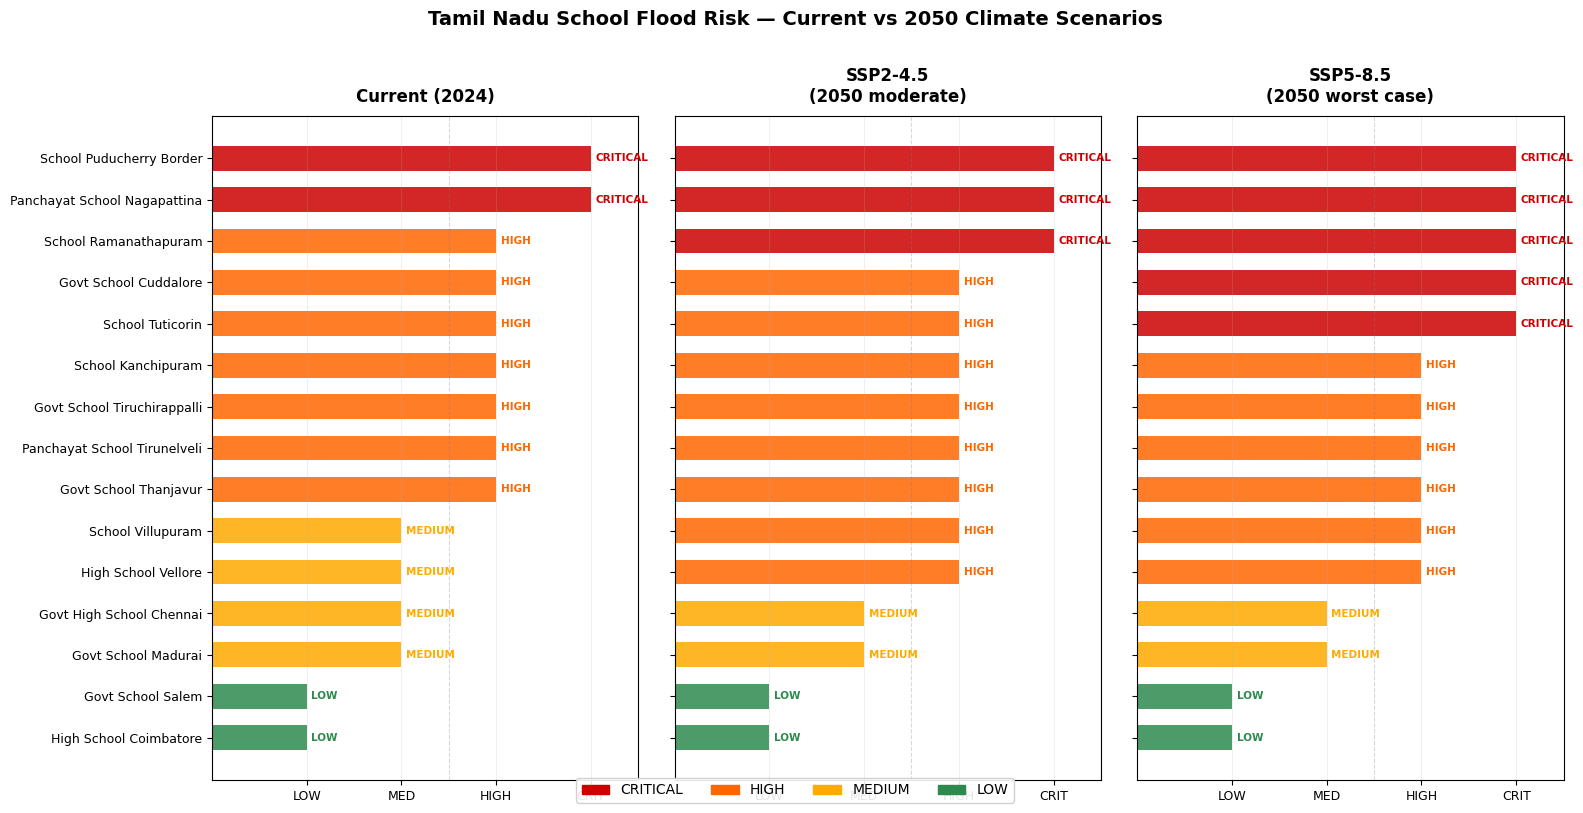

✅ 2050 projections chart saved!


In [7]:
# Before/After comparison chart
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Risk tier to number for plotting
risk_num = {'LOW': 1, 'MEDIUM': 2, 'HIGH': 3, 'CRITICAL': 4}
risk_color = {
    'LOW':      '#2d8a4e',
    'MEDIUM':   '#ffaa00',
    'HIGH':     '#ff6600',
    'CRITICAL': '#cc0000'
}

df['current_num'] = df['current_risk'].map(risk_num)
df['ssp245_num']  = df['risk_ssp245'].map(risk_num)
df['ssp585_num']  = df['risk_ssp585'].map(risk_num)

# Sort by current score
df_plot = df.sort_values('current_score', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

scenarios = [
    ('current_risk',  'current_num',  'Current (2024)',     '2024'),
    ('risk_ssp245',   'ssp245_num',   'SSP2-4.5\n(2050 moderate)', '2050'),
    ('risk_ssp585',   'ssp585_num',   'SSP5-8.5\n(2050 worst case)', '2050'),
]

for ax, (risk_col, num_col, title, year) in zip(axes, scenarios):
    colors = [risk_color[r] for r in df_plot[risk_col]]
    bars = ax.barh(
        range(len(df_plot)),
        df_plot[num_col],
        color=colors,
        alpha=0.85,
        height=0.6
    )
    ax.set_xlim(0, 4.5)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['LOW', 'MED', 'HIGH', 'CRIT'],
                       fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.axvline(x=2.5, color='gray', linestyle='--',
               alpha=0.3, linewidth=0.8)
    ax.grid(axis='x', alpha=0.2)

    # Add risk labels
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(
            df_plot[num_col].iloc[i] + 0.05,
            i,
            df_plot[risk_col].iloc[i],
            va='center', fontsize=7.5,
            color=risk_color[df_plot[risk_col].iloc[i]],
            fontweight='bold'
        )

# School names on left
axes[0].set_yticks(range(len(df_plot)))
axes[0].set_yticklabels(
    [s[:28] for s in df_plot['school_name']],
    fontsize=9
)

# Legend
patches = [
    mpatches.Patch(color='#cc0000', label='CRITICAL'),
    mpatches.Patch(color='#ff6600', label='HIGH'),
    mpatches.Patch(color='#ffaa00', label='MEDIUM'),
    mpatches.Patch(color='#2d8a4e', label='LOW'),
]
fig.legend(handles=patches, loc='lower center',
           ncol=4, fontsize=10, framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

fig.suptitle(
    'Tamil Nadu School Flood Risk — Current vs 2050 Climate Scenarios',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('tamil_nadu_2050_projections.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ 2050 projections chart saved!')

In [8]:
# Interactive 2050 risk map with scenario toggle
import folium
from folium.plugins import GroupedLayerControl

# Coordinates
coords = {
    'School Puducherry Border':      [11.93, 79.83],
    'Panchayat School Nagapattinam': [10.76, 79.84],
    'School Ramanathapuram':         [9.37,  78.83],
    'Govt School Cuddalore':         [11.75, 79.75],
    'School Tuticorin':              [8.80,  78.15],
    'School Kanchipuram':            [12.83, 79.70],
    'Govt School Tiruchirappalli':   [10.79, 78.68],
    'Panchayat School Tirunelveli':  [8.71,  77.69],
    'Govt School Thanjavur':         [10.78, 79.13],
    'High School Vellore':           [12.92, 79.13],
    'School Villupuram':             [11.93, 79.49],
    'Govt School Madurai':           [9.93,  78.12],
    'Govt High School Chennai':      [13.08, 80.27],
    'High School Coimbatore':        [11.01, 76.96],
    'Govt School Salem':             [11.65, 78.16],
}

df['latitude']  = df['school_name'].map(lambda x: coords[x][0])
df['longitude'] = df['school_name'].map(lambda x: coords[x][1])

# Color function
def get_color(risk):
    return {
        'CRITICAL': '#cc0000',
        'HIGH':     '#ff6600',
        'MEDIUM':   '#ffaa00',
        'LOW':      '#2d8a4e'
    }.get(risk, 'gray')

def get_radius(score):
    if score >= 50:  return 18
    elif score >= 25: return 14
    elif score >= 10: return 10
    else:             return 7

# Build map
m = folium.Map(
    location=[10.5, 78.5],
    zoom_start=7,
    tiles='CartoDB positron'
)

# Three layer groups — one per scenario
current_group = folium.FeatureGroup(name='Current (2024)', show=True)
ssp245_group  = folium.FeatureGroup(name='2050 SSP2-4.5 (+15%)', show=False)
ssp585_group  = folium.FeatureGroup(name='2050 SSP5-8.5 (+30%)', show=False)

for _, row in df.iterrows():
    conn = '⚠ No connectivity' if row['connectivity'] == 'none' else '✅ Connected'

    # Current scenario
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=get_radius(row['current_score']),
        color=get_color(row['current_risk']),
        fill=True,
        fill_color=get_color(row['current_risk']),
        fill_opacity=0.85,
        tooltip=row['school_name'],
        popup=folium.Popup(
            f"<b>{row['school_name']}</b><br>"
            f"<hr style='margin:4px 0'>"
            f"📡 {conn}<br>"
            f"📊 Score: {row['current_score']}<br>"
            f"🎯 Risk: <b>{row['current_risk']}</b>",
            max_width=250
        )
    ).add_to(current_group)

    # SSP2-4.5
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=get_radius(row['score_ssp245']),
        color=get_color(row['risk_ssp245']),
        fill=True,
        fill_color=get_color(row['risk_ssp245']),
        fill_opacity=0.85,
        tooltip=row['school_name'],
        popup=folium.Popup(
            f"<b>{row['school_name']}</b><br>"
            f"<hr style='margin:4px 0'>"
            f"📡 {conn}<br>"
            f"🌧 Rainfall +15% by 2050<br>"
            f"📊 Score: {row['score_ssp245']}<br>"
            f"🎯 2050 Risk: <b>{row['risk_ssp245']}</b>",
            max_width=250
        )
    ).add_to(ssp245_group)

    # SSP5-8.5
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=get_radius(row['score_ssp585']),
        color=get_color(row['risk_ssp585']),
        fill=True,
        fill_color=get_color(row['risk_ssp585']),
        fill_opacity=0.85,
        tooltip=row['school_name'],
        popup=folium.Popup(
            f"<b>{row['school_name']}</b><br>"
            f"<hr style='margin:4px 0'>"
            f"📡 {conn}<br>"
            f"🌧 Rainfall +30% by 2050<br>"
            f"📊 Score: {row['score_ssp585']}<br>"
            f"🎯 2050 Risk: <b>{row['risk_ssp585']}</b>",
            max_width=250
        )
    ).add_to(ssp585_group)

# Add groups to map
current_group.add_to(m)
ssp245_group.add_to(m)
ssp585_group.add_to(m)
folium.LayerControl().add_to(m)

# Legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;
     background:white;padding:14px;border-radius:10px;
     border:1px solid #ccc;font-size:12px;z-index:1000;
     box-shadow:2px 2px 6px rgba(0,0,0,0.15)">
     <b>🏫 School Flood Risk 2050</b><br>
     <i>Toggle scenarios top-right</i><br><br>
     <span style='color:#cc0000;font-size:16px'>●</span> Critical<br>
     <span style='color:#ff6600;font-size:16px'>●</span> High<br>
     <span style='color:#ffaa00;font-size:16px'>●</span> Medium<br>
     <span style='color:#2d8a4e;font-size:16px'>●</span> Low<br><br>
     <i>Size = risk magnitude</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save
m.save('tamil_nadu_2050_risk_map.html')
print('✅ 2050 scenario map saved!')
display(m)

✅ 2050 scenario map saved!


In [11]:
# Save all Day 5 outputs
from google.colab import files
import pandas as pd

# Save projections table as CSV
df.to_csv('tamil_nadu_2050_projections.csv', index=False)
print('✅ Projections CSV saved!')

# Download all files
files.download('tamil_nadu_2050_projections.png')
files.download('tamil_nadu_2050_risk_map.html')
files.download('tamil_nadu_2050_projections.csv')
print('✅ All files downloaded!')

# Print final summary
print()
print('=== DAY 5 SUMMARY — 2050 PROJECTIONS ===')
print()
print('Current CRITICAL schools:',
      len(df[df.current_risk == 'CRITICAL']))
print('2050 CRITICAL (SSP2-4.5):',
      len(df[df.risk_ssp245 == 'CRITICAL']))
print('2050 CRITICAL (SSP5-8.5):',
      len(df[df.risk_ssp585 == 'CRITICAL']))
print()
print('Schools escalating under SSP2-4.5:',
      df['tier_change_245'].sum())
print('Schools escalating under SSP5-8.5:',
      df['tier_change_585'].sum())
print()
print('Safest schools in all scenarios:')
safe = df[df.risk_ssp585 == 'LOW']['school_name'].values
for s in safe:
    print(f'  ✅ {s}')


✅ Projections CSV saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!

=== DAY 5 SUMMARY — 2050 PROJECTIONS ===

Current CRITICAL schools: 2
2050 CRITICAL (SSP2-4.5): 3
2050 CRITICAL (SSP5-8.5): 5

Schools escalating under SSP2-4.5: 3
Schools escalating under SSP5-8.5: 5

Safest schools in all scenarios:
  ✅ High School Coimbatore
  ✅ Govt School Salem
